# Notebook 3: Global Koning-Delaroche emulator

Calcium isotopes at Z=20 across mass number and laboratory energy.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom_legacy").is_dir()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import lrom_legacy.v2_0 as lrom

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

## Configuration

In [2]:
TARGET_Z = 20
PROJECTILE = (1, 0)
POTENTIAL = "woods-saxon"
CHANNEL = 0

CENTRAL_A = 40
CENTRAL_ENERGY = 14.1

TRAIN_A_LIMITS = (32, 48)
TRAIN_ENERGY_LIMITS = (10.0, 22.0)
TEST_A_LIMITS = (29, 61)
TEST_ENERGY_LIMITS = (8.0, 30.0)

N_TRAIN = 150
N_TEST = 120
SEED = 1204

MESH_SIZE = 600
BASIS_SIZE = 4
PREDICTOR_COUNT = 12

METHOD_COLORS = {"ls": "blue", "lrom": "#E6AB02"}
DISPLAY_ERROR_FLOOR = 1e-11

## Samples

In [3]:
def sample_plane(rng, a_limits, energy_limits, count):
    a_values = rng.integers(a_limits[0], a_limits[1] + 1, size=count)
    edges = np.linspace(energy_limits[0], energy_limits[1], count + 1)
    energies = rng.permutation(edges[:-1] + rng.random(count) * np.diff(edges))
    return np.column_stack((a_values.astype(float), energies))


rng = np.random.default_rng(SEED)
train_points = sample_plane(rng, TRAIN_A_LIMITS, TRAIN_ENERGY_LIMITS, N_TRAIN)
test_points = sample_plane(rng, TEST_A_LIMITS, TEST_ENERGY_LIMITS, N_TEST)
central_point = np.array([float(CENTRAL_A), CENTRAL_ENERGY])

## FOM

In [4]:
def build_fom(target_a, lab_energy):
    emulator = lrom.LROM(
        target=(int(target_a), TARGET_Z),
        projectile=PROJECTILE,
        lab_energy=float(lab_energy),
        l=CHANNEL,
        potential=POTENTIAL,
    )
    central = emulator.central_parameters
    emulator.sampling(
        training_grid={"Vv": [central["Vv"]]},
        testing_grid={"Vv": [central["Vv"]]},
        mesh_size=MESH_SIZE,
    )
    return emulator


def collect(points):
    wavefunctions = []
    potentials = []
    parameters = []
    wavenumbers = []
    for target_a, lab_energy in points:
        emulator = build_fom(target_a, lab_energy)
        samples = emulator.samples
        wavefunctions.append(samples.training_wavefunctions[CHANNEL][0])
        potentials.append(samples.training_potentials[0])
        parameters.append(
            [emulator.central_parameters[name] for name in emulator.parameter_names]
        )
        wavenumbers.append(emulator.kinematics.k)
    return (
        np.asarray(wavefunctions),
        np.asarray(potentials),
        np.asarray(parameters, dtype=float),
        np.asarray(wavenumbers, dtype=float),
    )


central_emulator = build_fom(*central_point)
PARAMETER_NAMES = central_emulator.parameter_names
scaled_grid = central_emulator.samples.mesh.rho
central_wavenumber = central_emulator.kinematics.k
central_radius = scaled_grid / central_wavenumber
central_wavefunction = central_emulator.samples.training_wavefunctions[CHANNEL][0]
central_potential = central_emulator.samples.training_potentials[0]

train_wavefunctions, train_potentials, train_parameters, train_wavenumbers = collect(train_points)
test_wavefunctions, test_potentials, test_parameters, test_wavenumbers = collect(test_points)


def radius_for(wavenumber):
    return scaled_grid / wavenumber

## Design plot

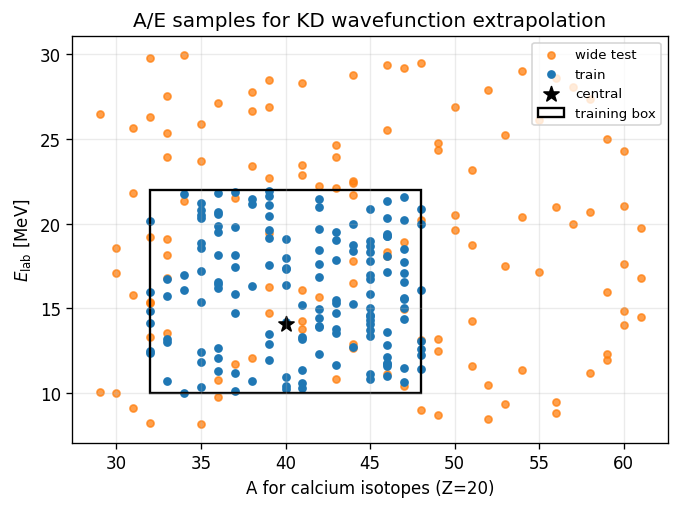

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.scatter(test_points[:, 0], test_points[:, 1], s=18, color="tab:orange", alpha=0.75, label="wide test")
ax.scatter(train_points[:, 0], train_points[:, 1], s=18, color="tab:blue", label="train")
ax.scatter(central_point[0], central_point[1], marker="*", s=90, color="black", label="central")
ax.add_patch(
    plt.Rectangle(
        (TRAIN_A_LIMITS[0], TRAIN_ENERGY_LIMITS[0]),
        TRAIN_A_LIMITS[1] - TRAIN_A_LIMITS[0],
        TRAIN_ENERGY_LIMITS[1] - TRAIN_ENERGY_LIMITS[0],
        fill=False, edgecolor="black", linewidth=1.4, label="training box",
    )
)
ax.set_xlabel("A for calcium isotopes (Z=20)")
ax.set_ylabel(r"$E_{\mathrm{lab}}$ [MeV]")
ax.set_title("A/E samples for KD wavefunction extrapolation")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## Central potential parameters

In [6]:
pd.DataFrame(
    [central_emulator.central_parameters],
    index=[f"A={CENTRAL_A}, E={CENTRAL_ENERGY} MeV"],
).round(3)

,Vv,Rv,av,Wv,Rwv,awv,Wd,Rd,ad,Vso,Rso,aso,Wso,Rwso,awso
"A=40, E=14.1 MeV",48.822,4.054,0.672,1.175,4.054,0.672,7.695,4.406,0.538,5.482,3.407,0.59,-0.07,3.407,0.59


# Step 2: emulating wavefunctions across the plane

## Basis and coefficients

In [8]:
basis = lrom.build_basis(
    phi0=central_wavefunction,
    snapshots=train_wavefunctions,
    radius=scaled_grid,
    basis_size=BASIS_SIZE,
)

ls_train_coefficients = lrom.project_coordinates(basis=basis, wavefunctions=train_wavefunctions)
ls_test_coefficients = lrom.project_coordinates(basis=basis, wavefunctions=test_wavefunctions)

predictor = lrom.build_potential_predictor(
    radius=scaled_grid,
    central_potential=central_potential,
    training_potentials=train_potentials,
    testing_potentials=test_potentials,
    predictor_count=PREDICTOR_COUNT,
)

model = lrom.fit(predictors=predictor.training_features, coordinates=ls_train_coefficients)

lrom_train_coefficients = lrom.solve(model=model, predictors=predictor.training_features)
lrom_test_coefficients = lrom.solve(model=model, predictors=predictor.testing_features)

ls_train_wavefunctions = lrom.reconstruct(basis=basis, coordinates=ls_train_coefficients)
ls_test_wavefunctions = lrom.reconstruct(basis=basis, coordinates=ls_test_coefficients)
lrom_train_wavefunctions = lrom.reconstruct(basis=basis, coordinates=lrom_train_coefficients)
lrom_test_wavefunctions = lrom.reconstruct(basis=basis, coordinates=lrom_test_coefficients)

errors = {
    ("ls", "training"): lrom.relative_l2(prediction=ls_train_wavefunctions, reference=train_wavefunctions),
    ("ls", "testing"): lrom.relative_l2(prediction=ls_test_wavefunctions, reference=test_wavefunctions),
    ("lrom", "training"): lrom.relative_l2(prediction=lrom_train_wavefunctions, reference=train_wavefunctions),
    ("lrom", "testing"): lrom.relative_l2(prediction=lrom_test_wavefunctions, reference=test_wavefunctions),
}

predictor_radii = predictor.selected_radii / central_wavenumber

print("singular values:", basis.singular_values)
print("predictor radii at the central case [fm]:", np.round(np.sort(predictor_radii), 3))
print("residual mse:", model.residual_mse)

singular values: [54.87418784  7.52760746  4.37700782  1.64734485]
predictor radii at the central case [fm]: [0.    1.559 2.547 3.17  3.69  4.106 4.522 4.937 5.457 6.029 6.756 8.004]
residual mse: 6.055748427406522e-13


## Basis vectors

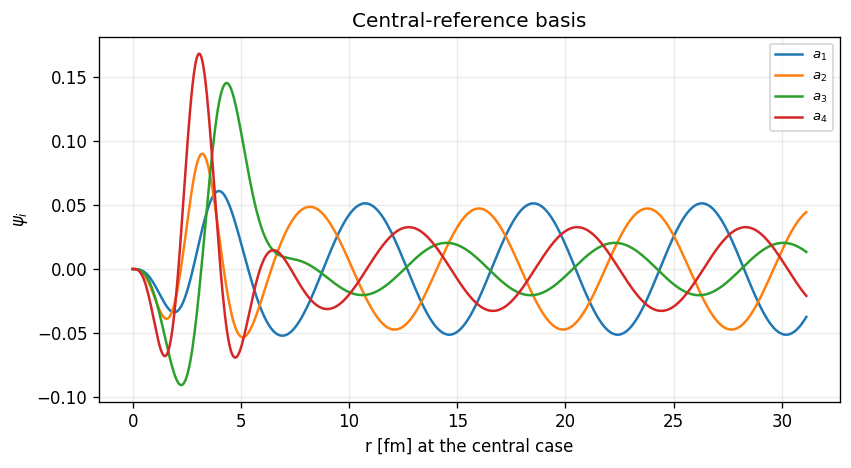

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for index in range(BASIS_SIZE):
    ax.plot(central_radius, np.real(basis.vectors[:, index]), label=rf"$a_{{{index + 1}}}$")
ax.set_xlabel("r [fm] at the central case")
ax.set_ylabel(r"$\psi_i$")
ax.set_title("Central-reference basis")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Potential predictors

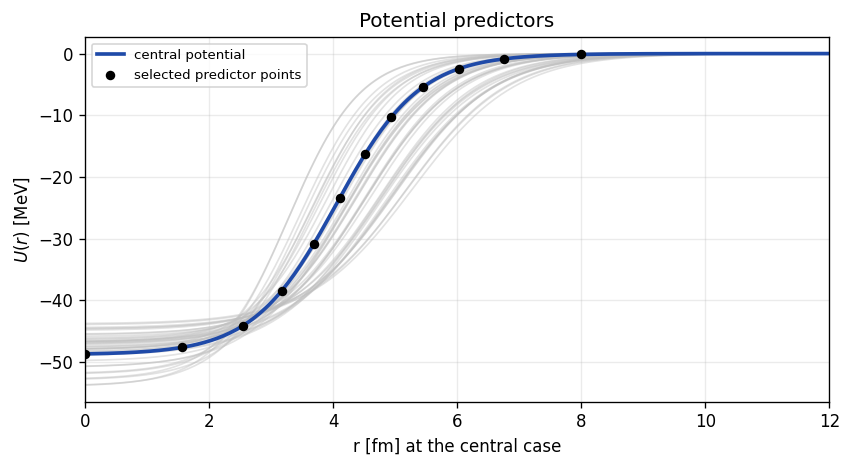

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for potential in train_potentials[:40]:
    ax.plot(central_radius, np.real(potential), color="0.75", alpha=0.45, linewidth=1.0)
ax.plot(central_radius, np.real(central_potential), color="#1f4aa8", linewidth=2.2, label="central potential")
ax.scatter(
    predictor_radii,
    np.interp(predictor_radii, central_radius, np.real(central_potential)),
    color="black", s=22, zorder=4, label="selected predictor points",
)
ax.set_xlabel("r [fm] at the central case")
ax.set_ylabel(r"$U(r)$ [MeV]")
ax.set_title("Potential predictors")
ax.set_xlim(0.0, 12.0)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Coefficient scans

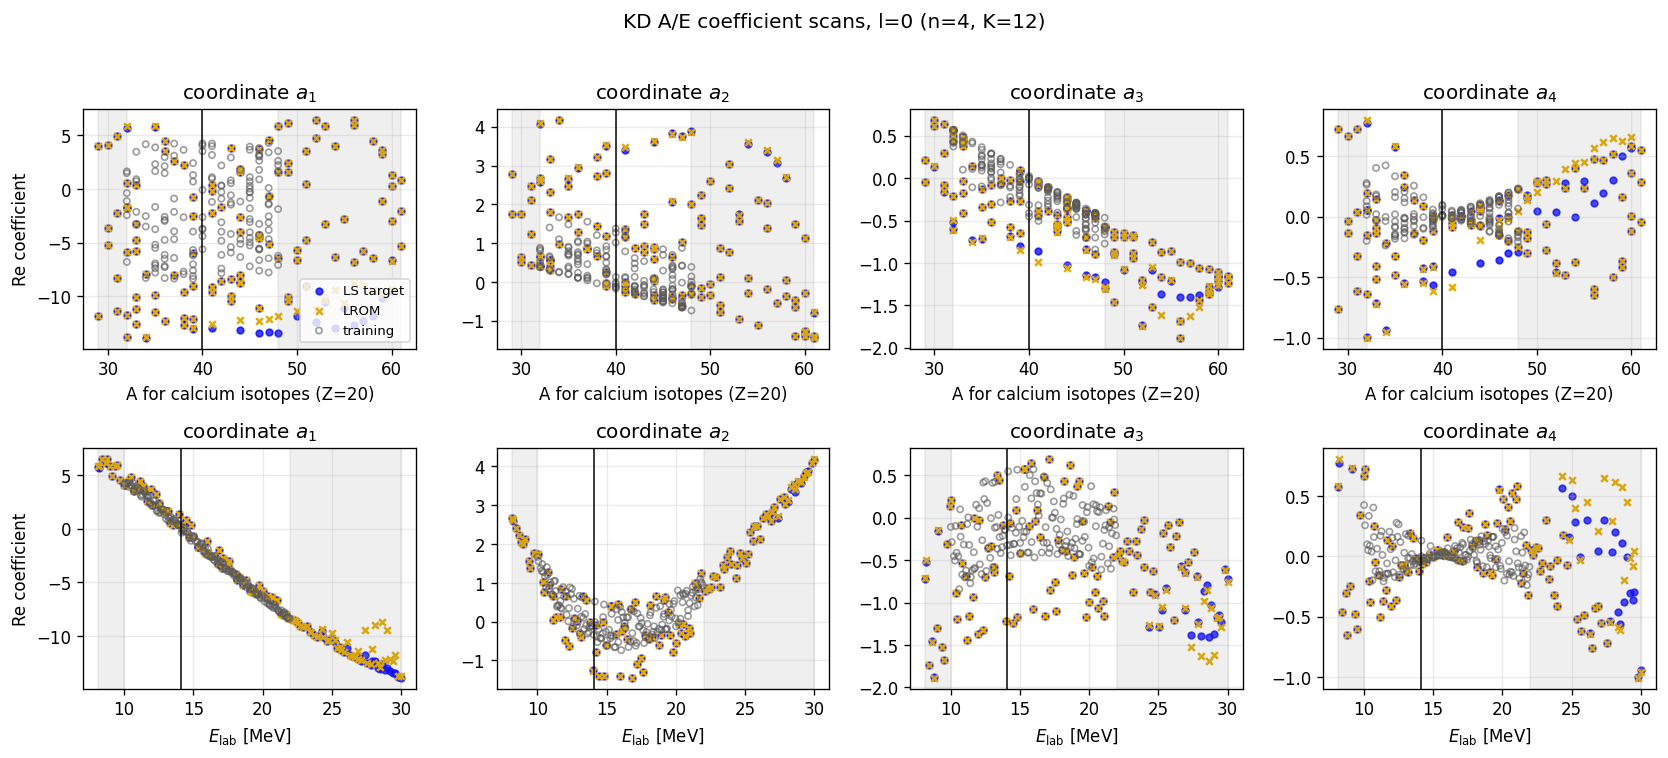

In [11]:
axis_data = (
    (0, "A for calcium isotopes (Z=20)", TRAIN_A_LIMITS, CENTRAL_A),
    (1, r"$E_{\mathrm{lab}}$ [MeV]", TRAIN_ENERGY_LIMITS, CENTRAL_ENERGY),
)

fig, axes = plt.subplots(2, BASIS_SIZE, figsize=(14.0, 6.4), sharex="row")
for row, (column_index, xlabel, limits, central_value) in enumerate(axis_data):
    train_axis = train_points[:, column_index]
    test_axis = test_points[:, column_index]
    for index in range(BASIS_SIZE):
        ax = axes[row, index]
        ax.scatter(
            test_axis, np.real(ls_test_coefficients[:, index]),
            s=16, color=METHOD_COLORS["ls"], alpha=0.75,
            label="LS target" if index == 0 else None,
        )
        ax.scatter(
            test_axis, np.real(lrom_test_coefficients[:, index]),
            s=16, marker="x", color=METHOD_COLORS["lrom"],
            label="LROM" if index == 0 else None,
        )
        ax.scatter(
            train_axis, np.real(ls_train_coefficients[:, index]),
            s=14, facecolors="none", edgecolors="0.35", alpha=0.6,
            label="training" if index == 0 else None,
        )
        ax.axvspan(test_axis.min(), limits[0], color="gray", alpha=0.12)
        ax.axvspan(limits[1], test_axis.max(), color="gray", alpha=0.12)
        ax.axvline(central_value, color="black", linewidth=0.9)
        ax.set_title(rf"coordinate $a_{{{index + 1}}}$")
        ax.set_xlabel(xlabel)
    axes[row, 0].set_ylabel("Re coefficient")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"KD A/E coefficient scans, l={CHANNEL} (n={BASIS_SIZE}, K={PREDICTOR_COUNT})")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Wavefunction errors

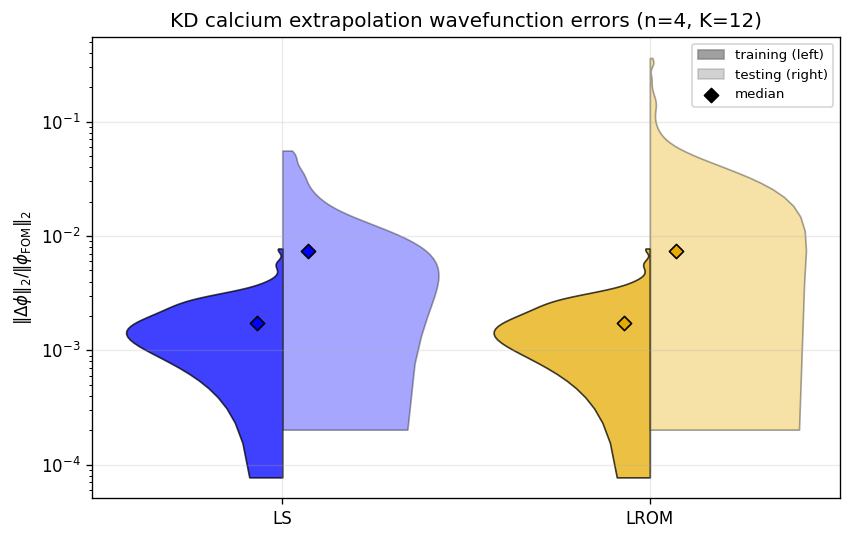

In [12]:
methods = ("ls", "lrom")
positions = np.arange(1, len(methods) + 1)
colors = tuple(METHOD_COLORS[method] for method in methods)
training_values = [np.maximum(errors[(method, "training")], np.finfo(float).tiny) for method in methods]
testing_values = [np.maximum(errors[(method, "testing")], np.finfo(float).tiny) for method in methods]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
training_violin = ax.violinplot(training_values, positions=positions, widths=0.85, showextrema=False)
testing_violin = ax.violinplot(testing_values, positions=positions, widths=0.85, showextrema=False)
for center, body, color in zip(positions, training_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.minimum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.75)
for center, body, color in zip(positions, testing_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.maximum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.35)
for center, values, color in zip(positions, training_values, colors):
    ax.scatter(center - 0.07, np.median(values), marker="D", color=color, edgecolor="black", zorder=6)
for center, values, color in zip(positions, testing_values, colors):
    ax.scatter(center + 0.07, np.median(values), marker="D", color=color, edgecolor="black", zorder=6)
ax.set_xticks(positions, [method.upper() for method in methods])
ax.set_yscale("log", nonpositive="clip")
ax.set_ylabel(r"$\|\Delta\phi\|_2 / \|\phi_{\mathrm{FOM}}\|_2$")
ax.set_title(f"KD calcium extrapolation wavefunction errors (n={BASIS_SIZE}, K={PREDICTOR_COUNT})")
ax.fill_between([], [], color="gray", alpha=0.75, label="training (left)")
ax.fill_between([], [], color="gray", alpha=0.35, label="testing (right)")
ax.scatter([], [], marker="D", color="black", label="median")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Representative wavefunctions

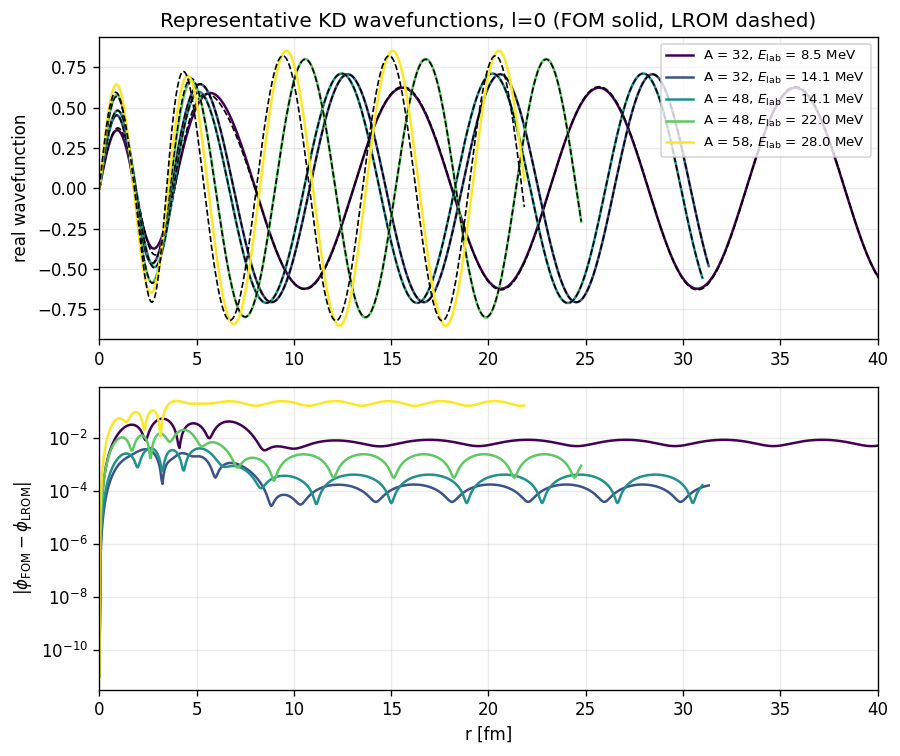

In [13]:
representative = ((32, 8.5), (32, 14.1), (48, 14.1), (48, 22.0), (58, 28.0))
representative_points = np.asarray(representative, dtype=float)
(
    representative_wavefunctions,
    representative_potentials,
    _,
    representative_wavenumbers,
) = collect(representative_points)

representative_features = (
    representative_potentials[:, predictor.selected_indices]
    - central_potential[predictor.selected_indices][np.newaxis, :]
) / predictor.scales
representative_lrom = lrom.reconstruct(
    basis=basis,
    coordinates=lrom.solve(model=model, predictors=representative_features),
)

fig, axes = plt.subplots(2, 1, figsize=(7.6, 6.4))
for index, (target_a, lab_energy) in enumerate(representative):
    color = plt.cm.viridis(index / (len(representative) - 1))
    case_radius = radius_for(representative_wavenumbers[index])
    axes[0].plot(
        case_radius, np.real(representative_wavefunctions[index]), color=color,
        label=rf"A = {target_a}, $E_{{\mathrm{{lab}}}}$ = {lab_energy} MeV",
    )
    axes[0].plot(case_radius, np.real(representative_lrom[index]), "--", color="black", linewidth=1.0)
    axes[1].plot(
        case_radius,
        np.maximum(
            np.abs(representative_wavefunctions[index] - representative_lrom[index]),
            DISPLAY_ERROR_FLOOR,
        ),
        color=color,
    )
axes[0].set_ylabel("real wavefunction")
axes[0].set_title(f"Representative KD wavefunctions, l={CHANNEL} (FOM solid, LROM dashed)")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.0, 40.0)
axes[1].set_xlabel("r [fm]")
axes[1].set_ylabel(r"$|\phi_{\mathrm{FOM}} - \phi_{\mathrm{LROM}}|$")
axes[1].set_yscale("log")
axes[1].set_xlim(0.0, 40.0)
fig.tight_layout()
plt.show()